Model Performance:
MAE: 244722.09950804553
RMSE: 283321.9077174262


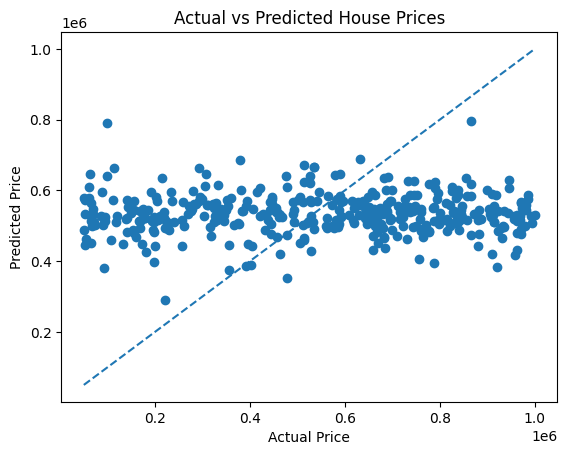


Predicted House Price: 460381.9244950222


In [1]:

# HOUSE PRICE PREDICTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("/House Price Prediction Dataset.csv")

# Feature Selection
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
        'Location', 'Condition', 'Garage']]
y = df['Price']

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# Handle missing values
X = X.fillna(X.mean())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Model (Gradient Boosting)
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance:")
print("MAE:", mae)
print("RMSE:", rmse)

# Visualization
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# TEST WITH NEW INPUT
sample = pd.DataFrame([{
    'Area': 3000,
    'Bedrooms': 4,
    'Bathrooms': 3,
    'Floors': 2,
    'YearBuilt': 2010,
    'Location': 'Suburban',
    'Condition': 'Good',
    'Garage': 'Yes'
}])

# Convert same way as training
sample = pd.get_dummies(sample)

# Match columns
sample = sample.reindex(columns=X.columns, fill_value=0)

# Scale
sample_scaled = scaler.transform(sample)

# Predict
predicted_price = model.predict(sample_scaled)

print("\nPredicted House Price:", predicted_price[0])

In [2]:
sample = pd.DataFrame([{
    'Area': 2500,
    'Bedrooms': 3,
    'Bathrooms': 2,
    'Floors': 1,
    'YearBuilt': 2015,
    'Location': 'Urban',
    'Condition': 'Excellent',
    'Garage': 'Yes'
}])

# Convert categorical same as training
sample = pd.get_dummies(sample)

# Match training columns
sample = sample.reindex(columns=X.columns, fill_value=0)

# Scale
sample_scaled = scaler.transform(sample)

# Predict
predicted_price = model.predict(sample_scaled)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 421550.36907788244
